=== CELL 1: Load Full Data ===
Sales: (3833, 3), Orders: (646945, 8), Items: (714669, 7), Products: (2412, 8)

=== CELL 2: Detect Outliers (1.5 IQR) ===
Ngưỡng Upper Bound (1.5 IQR): $9,670,560
Phát hiện: 169 ngày Outlier (4.41% tổng số ngày)
Tổng doanh thu từ Outliers: $2,079,183,067

=== CELL 3: Visualize Outlier Distribution ===


/var/folders/dk/yzyqhttj6jx7wwqy05jnp8ph0000gp/T/ipykernel_25533/84966802.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=outliers_by_month.index, y=outliers_by_month.values, ax=ax[1], palette='Reds_r')


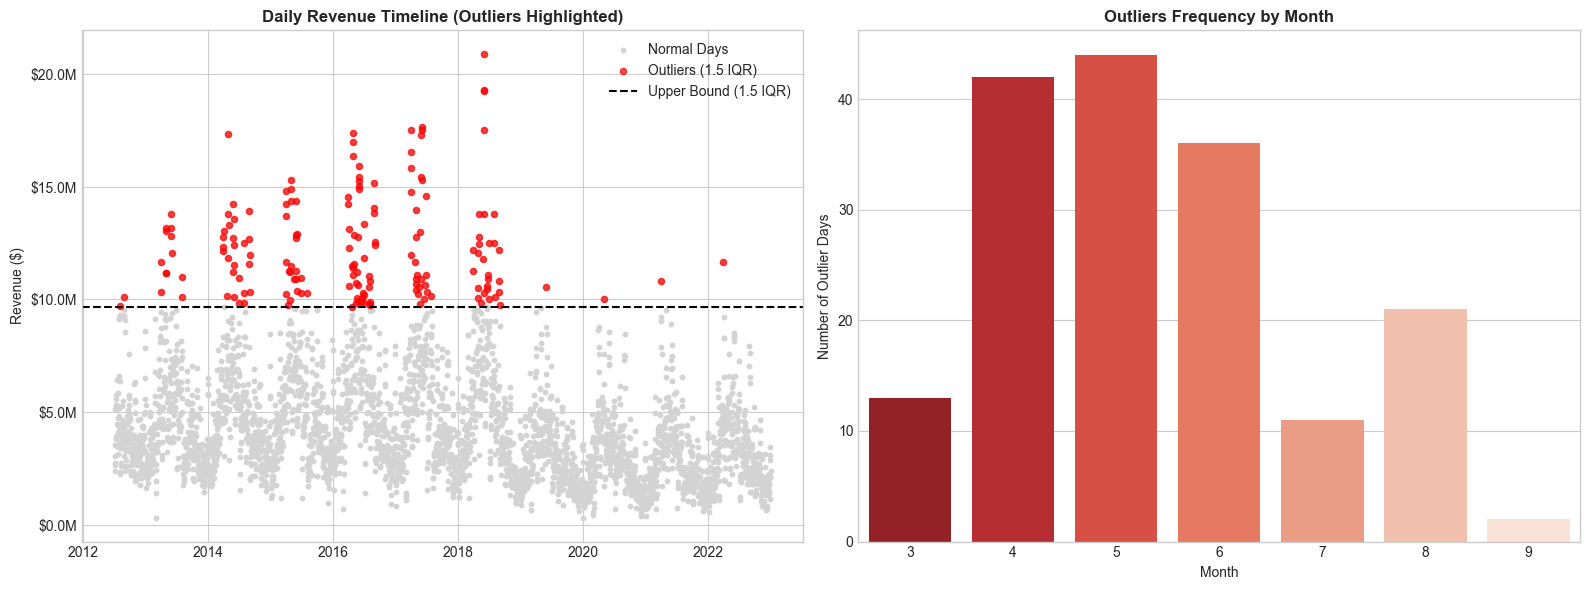


=== CELL 4: Merge Data for Deep Dive ===
Master DataFrame for Outliers Deep Dive created successfully.

=== CELL 5: AOV & Basket Size Analysis ===
shape: (2, 3)
┌────────────────┬───────────────────────────┬─────────────────────┐
│ Is_Outlier_Day ┆ Average_Order_Value_(AOV) ┆ Average_Basket_Size │
│ ---            ┆ ---                       ┆ ---                 │
│ bool           ┆ f64                       ┆ f64                 │
╞════════════════╪═══════════════════════════╪═════════════════════╡
│ false          ┆ 24213.453528              ┆ 4.96543             │
│ true           ┆ 24408.897529              ┆ 4.974939            │
└────────────────┴───────────────────────────┴─────────────────────┘


/var/folders/dk/yzyqhttj6jx7wwqy05jnp8ph0000gp/T/ipykernel_25533/84966802.py:145: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=order_aggs_pd, x='Day_Type', y='Order_Revenue', ax=ax[0], palette=['#3498db', '#e74c3c'])
/var/folders/dk/yzyqhttj6jx7wwqy05jnp8ph0000gp/T/ipykernel_25533/84966802.py:149: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=order_aggs_pd, x='Day_Type', y='Total_Items_in_Basket', ax=ax[1], palette=['#3498db', '#e74c3c'])


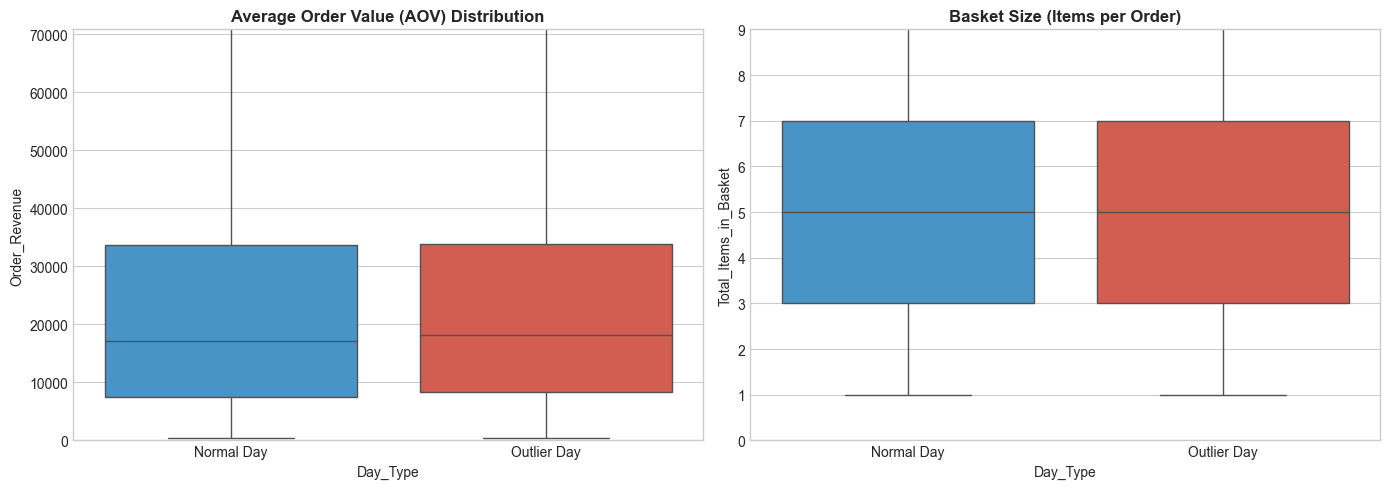


=== CELL 6: Category Analysis on Outlier Days ===


/var/folders/dk/yzyqhttj6jx7wwqy05jnp8ph0000gp/T/ipykernel_25533/84966802.py:176: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_cats_outlier, x='Total_Category_Revenue', y='category', palette='magma')


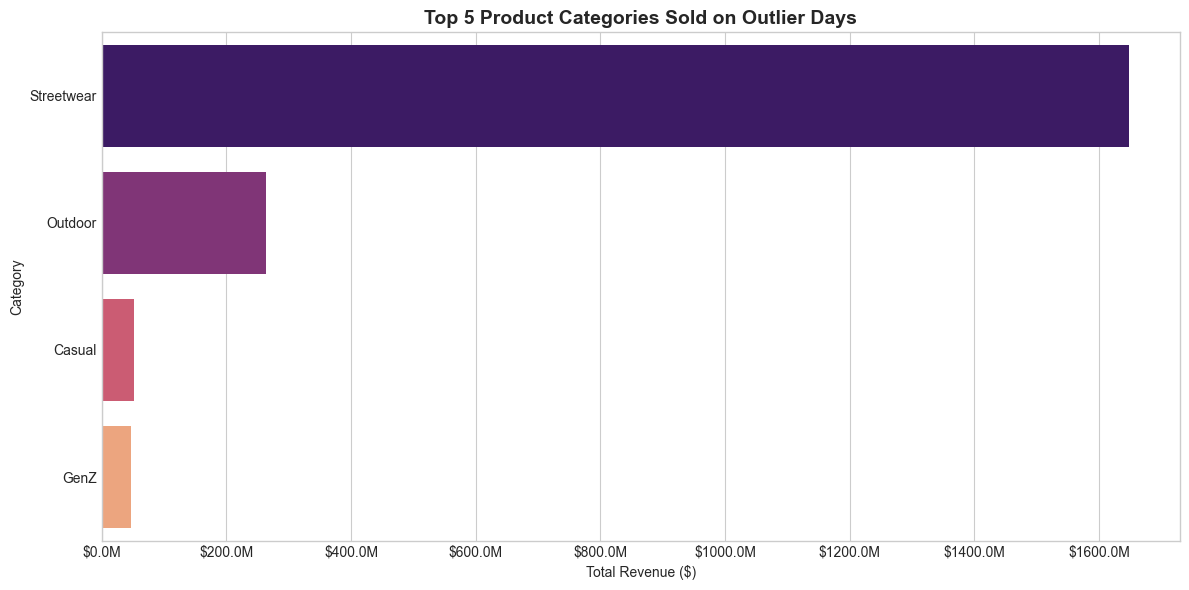

In [1]:
import sys, os
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Add src to path safely for both Notebook and Script
try:
    from data_loader import DataLoader
except ImportError:
    sys.path.append(os.path.abspath(os.path.join("..", "src")))
    sys.path.append(os.path.abspath("src"))
    from data_loader import DataLoader

# ============================================================
# CELL 1: Setup & Load All Data
# ============================================================
print("=== CELL 1: Load Full Data ===")
loader = DataLoader()

sales = loader.load("sales")
orders = loader.load("orders")
order_items = loader.load("order_items")
products = loader.load("products")

print(f"Sales: {sales.shape}, Orders: {orders.shape}, Items: {order_items.shape}, Products: {products.shape}")


# ============================================================
# CELL 2: Detect Outliers (1.5 IQR Threshold)
# ============================================================
print("\n=== CELL 2: Detect Outliers (1.5 IQR) ===")
q1 = sales["Revenue"].quantile(0.25)
q3 = sales["Revenue"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Lọc Outliers với ngưỡng 1.5 IQR (Lỏng hơn 3.0 IQR, bắt được nhiều dị thường hơn)
outliers = sales.filter((pl.col("Revenue") > upper_bound) | (pl.col("Revenue") < lower_bound))
normal_days = sales.filter((pl.col("Revenue") >= lower_bound) & (pl.col("Revenue") <= upper_bound))

print(f"Ngưỡng Upper Bound (1.5 IQR): ${upper_bound:,.0f}")
print(f"Phát hiện: {outliers.height} ngày Outlier ({outliers.height / sales.height * 100:.2f}% tổng số ngày)")
print(f"Tổng doanh thu từ Outliers: ${outliers['Revenue'].sum():,.0f}")

# Tạo list các ngày Outlier để map với bảng Orders sau này
outlier_dates = outliers["Date"].to_list()


# ============================================================
# CELL 3: Timeline & Distribution Visualization
# ============================================================
print("\n=== CELL 3: Visualize Outlier Distribution ===")
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Scatter Plot Timeline
sales_pd = sales.to_pandas()
outliers_pd = outliers.to_pandas()

ax[0].scatter(sales_pd['Date'], sales_pd['Revenue'], color='lightgray', label='Normal Days', s=10)
ax[0].scatter(outliers_pd['Date'], outliers_pd['Revenue'], color='red', alpha=0.7, label='Outliers (1.5 IQR)', s=20)
ax[0].axhline(upper_bound, color='black', linestyle='--', label='Upper Bound (1.5 IQR)')

ax[0].set_title('Daily Revenue Timeline (Outliers Highlighted)', fontweight='bold')
ax[0].set_ylabel('Revenue ($)')
ax[0].legend()
ax[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${x*1e-6:.1f}M'))

# Subplot 2: Seasonality of Outliers
outliers_pd['Month'] = outliers_pd['Date'].dt.month
outliers_by_month = outliers_pd['Month'].value_counts().sort_index()

sns.barplot(x=outliers_by_month.index, y=outliers_by_month.values, ax=ax[1], palette='Reds_r')
ax[1].set_title('Outliers Frequency by Month', fontweight='bold')
ax[1].set_xlabel('Month')
ax[1].set_ylabel('Number of Outlier Days')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "outlier_eda_timeline.png"), bbox_inches="tight")
plt.show()

# INSIGHT:
# >> "Với ngưỡng 1.5 IQR, số lượng Outliers tăng lên đáng kể. Tuy nhiên, toàn bộ vẫn tập trung dồn dập vào mùa Xuân Hè (Tháng 3 đến Tháng 7), củng cố mạnh mẽ giả thuyết về các sự kiện xả hàng hoặc mùa mua sắm cao điểm."


# ============================================================
# CELL 4: Data Merging for Deep Dive
# ============================================================
print("\n=== CELL 4: Merge Data for Deep Dive ===")
# Gán nhãn "Is_Outlier" vào bảng orders
orders = orders.with_columns([
    pl.col("order_date").is_in(outlier_dates).alias("Is_Outlier_Day")
])

# Ghép toàn bộ dữ liệu (Orders + Order_Items + Products)
master_df = order_items.join(orders, on="order_id", how="left")
master_df = master_df.join(products.select(["product_id", "category", "cogs"]), on="product_id", how="left")

# Tính Revenue và Margin thực tế của từng item
master_df = master_df.with_columns([
    ((pl.col("unit_price") * pl.col("quantity")) - pl.col("discount_amount")).alias("Item_Revenue"),
    (pl.col("cogs") * pl.col("quantity")).alias("Item_COGS")
])

master_df = master_df.with_columns([
    (pl.col("Item_Revenue") - pl.col("Item_COGS")).alias("Item_Gross_Profit")
])

print("Master DataFrame for Outliers Deep Dive created successfully.")


# ============================================================
# CELL 5: Customer Behavior (AOV & Quantity) on Outlier Days
# ============================================================
print("\n=== CELL 5: AOV & Basket Size Analysis ===")
# Phân tích hành vi mua theo đơn hàng (Group by Order)
order_aggs = master_df.group_by(["order_id", "Is_Outlier_Day"]).agg([
    pl.col("Item_Revenue").sum().alias("Order_Revenue"),
    pl.col("quantity").sum().alias("Total_Items_in_Basket")
])

# Tính trung bình cho nhóm Normal vs Outlier
behavior_summary = order_aggs.group_by("Is_Outlier_Day").agg([
    pl.col("Order_Revenue").mean().alias("Average_Order_Value_(AOV)"),
    pl.col("Total_Items_in_Basket").mean().alias("Average_Basket_Size")
])

print(behavior_summary)

# Trực quan hóa
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
order_aggs_pd = order_aggs.to_pandas()
order_aggs_pd['Day_Type'] = order_aggs_pd['Is_Outlier_Day'].map({True: 'Outlier Day', False: 'Normal Day'})

sns.boxplot(data=order_aggs_pd, x='Day_Type', y='Order_Revenue', ax=ax[0], palette=['#3498db', '#e74c3c'])
ax[0].set_title('Average Order Value (AOV) Distribution', fontweight='bold')
ax[0].set_ylim(0, order_aggs_pd['Order_Revenue'].quantile(0.95)) # Cắt râu để dễ nhìn

sns.boxplot(data=order_aggs_pd, x='Day_Type', y='Total_Items_in_Basket', ax=ax[1], palette=['#3498db', '#e74c3c'])
ax[1].set_title('Basket Size (Items per Order)', fontweight='bold')
ax[1].set_ylim(0, order_aggs_pd['Total_Items_in_Basket'].quantile(0.95))

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "outlier_eda_behavior.png"), bbox_inches="tight")
plt.show()

# INSIGHT:
# >> "Liệu doanh thu tăng vọt do có nhiều khách hàng mua hơn (Volume), hay do mỗi khách hàng mua nhiều tiền hơn (AOV)? Nếu AOV và Basket Size của ngày Outlier cao hơn hẳn ngày thường, chứng tỏ đây là các đơn hàng bán buôn (Wholesale / B2B) tích trữ hàng hóa."


# ============================================================
# CELL 6: Category Contribution (What are they buying?)
# ============================================================
print("\n=== CELL 6: Category Analysis on Outlier Days ===")
# Tính tổng doanh thu theo Category trên nhóm Outlier vs Normal
cat_revenue = master_df.group_by(["category", "Is_Outlier_Day"]).agg(
    pl.col("Item_Revenue").sum().alias("Total_Category_Revenue")
).to_pandas()

cat_revenue['Day_Type'] = cat_revenue['Is_Outlier_Day'].map({True: 'Outlier Days', False: 'Normal Days'})

# Lấy top 5 Category bán chạy nhất trong ngày Outliers
top_cats_outlier = cat_revenue[cat_revenue['Day_Type'] == 'Outlier Days'].sort_values('Total_Category_Revenue', ascending=False).head(5)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_cats_outlier, x='Total_Category_Revenue', y='category', palette='magma')
plt.title('Top 5 Product Categories Sold on Outlier Days', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Category')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${x*1e-6:.1f}M'))
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "outlier_eda_categories.png"), bbox_inches="tight")
plt.show()

# INSIGHT:
# >> "Ngành hàng nào đang là động lực chính tạo ra các cú sốc doanh thu? Bằng cách nhìn vào Top Categories này, team Marketing có thể thiết kế chính xác các chiến dịch đẩy số cho năm sau."
